In [1]:
n_jobs=1
n_components_list=[2, 3, 5]

In [2]:
from pathlib import Path
from os import environ

ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixpoisson")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/rlct")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/rlct


In [3]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [4]:
from sklearn_extensions.mixpoisson import PoissonMixture
from scipy_extensions import mixpoisson


def find_truth_by_dsid(dsid: str):
  dgp = dgps.query(f"dsid=='{dsid}'")
  truth = dgp[["m0", "m1", "w0", "w1"]].iloc[0].tolist()
  return truth

def n_components_by_dsid(dsid: str):
  truth = find_truth_by_dsid(dsid)
  half_space = int(np.ceil(len(truth)/2))
  mus = truth[0: half_space]
  weights = truth[half_space: len(truth)]
  return mixpoisson.n_components(mus=mus, weights=weights)

def rlct_by_dsid(dsid: str, k: int):
  n_components0 = n_components_by_dsid(dsid)
  return mixpoisson.rlct(d=1, r=n_components0, k=k)

In [5]:
import pandas as pd
import json
from pathlib import Path

rlcthat_filename = "toru_watanabe.csv"
rlcthat_file = Path(f"{outputdir}/{rlcthat_filename}")

# Load existing results if file exists
if rlcthat_file.exists():
  rlcthat_df = pd.read_csv(rlcthat_file)
  # Create a set of completed (run, regime, dsid) tuples for fast lookup
  completed = set(
      zip(rlcthat_df["trial"], rlcthat_df["name"], rlcthat_df["regime"], rlcthat_df["k"], rlcthat_df["hypers"], rlcthat_df["dsid"])
  )
  rlcthat_data = rlcthat_df.to_dict("records")
else:
  completed = set()
  rlcthat_data = []

def save_results():
  """Save current results to disk."""
  pd.DataFrame(rlcthat_data).to_csv(rlcthat_file, index=False)

In [6]:
from joblib import Parallel, delayed
import time


def run_single_dsid(name, dsid, run, regime, c, d, k, datadir, n_draws, n_tune, n_chains):
  dataset = pd.read_csv(f"{datadir}/{dsid}-{regime}.csv")
  X = dataset.iloc[:, run].to_numpy()
  
  start = time.perf_counter()
  result = {
    "dsid": dsid,
    "regime": regime,
    'k': k,
    "n": regime,
    "trial": run,
    "chains": n_chains,
    "draws": n_draws,
    "tune": n_tune,
  }
  rlct = None
  match name:
    case "watanabe":
      rlct = run_watanabe(X, c, d, k, n_draws, n_tune, n_chains)
    case "toru":
      rlct = run_toru(X, c, k, n_draws, n_tune, n_chains)
    case _:
      raise Exception(f"Unsupported RLCT estimator {name}")
  end = time.perf_counter()

  print(f"run={run}, regime={regime}, k={k}, c={c}, d={d}, dsid={dsid}, rlct={rlct['rlct']}, name={name}, duration={end - start:.6f}")
  result = rlct | result
  result["name"]=name
  result["duration"]=end - start
  return result

def run_watanabe(X, c, d, k, n_draws, n_tune, n_chains):
  hypers=f"c={c},d={d}"
  n_obs = len(X)

  # watanabe RLCT first
  beta = c / np.log(n_obs)
  delta = d / np.log(n_obs)
  
  # First MCMC run at beta
  with TemperedPoissonMixture(X=X, beta=beta, n_components=k) as model:
    idata0 = model.sample(
      draws=n_draws,
      tune=n_tune,
      chains=n_chains,
      progressbar=False,
      nuts_sampler="nutpie",
      cores=1
    )
    weights = pmx.column_stack_vars(idata0, ["weights"])
    mus = pmx.column_stack_vars(idata0, ["mus"])
    log_likelihood = mixpoisson.log_likelihood(weights, mus, x=X)
    ll0 = log_likelihood.mean()
  
  diverging0 = idata0.sample_stats.diverging.values
  divs_per_chain0 = diverging0.sum(axis=1)
  mean_divergences0 = divs_per_chain0.mean()
  total_divergences0 = diverging0.sum()
  max_divergences0 = divs_per_chain0.max()
  tree_depth0 = idata0.sample_stats.depth.values.max()
  
  # Second MCMC run at beta + delta
  with TemperedPoissonMixture(X=X, beta=beta + delta) as model:
    idata1 = model.sample(
      draws=n_draws,
      tune=n_tune,
      chains=n_chains,
      progressbar=False,
      nuts_sampler="nutpie",
      cores=1
    )
    weights = pmx.column_stack_vars(idata1, ["weights"])
    mus = pmx.column_stack_vars(idata1, ["mus"])
    log_likelihood = mixpoisson.log_likelihood(weights, mus, x=X)
    ll1 = log_likelihood.mean()
  
  diverging1 = idata1.sample_stats.diverging.values
  divs_per_chain1 = diverging1.sum(axis=1)
  mean_divergences1 = divs_per_chain1.mean()
  total_divergences1 = diverging1.sum()
  max_divergences1 = divs_per_chain1.max()
  tree_depth1 = idata1.sample_stats.depth.values.max()
  
  rlct = (ll0 - ll1) / (1 / (beta + delta) - 1 / beta)
  
  return {
    "rlct": rlct,
    "hypers": hypers,
    "mean_divergences": (mean_divergences0 + mean_divergences1) / 2,
    "total_divergences": total_divergences0 + total_divergences1,
    "max_divergences": max(max_divergences0, max_divergences1),
    "divergences_per_chain": divs_per_chain0.tolist() + divs_per_chain1.tolist(),
    "chain_tree_depth": max(tree_depth0, tree_depth1),
  }


def run_toru(X, c, k, n_draws, n_tune, n_chains):
  hypers = f"c={c}"
  n_obs = len(X)
  
  # watanabe RLCT first
  beta = c / np.log(n_obs)
  
  # First MCMC run at beta
  with TemperedPoissonMixture(X=X, beta=beta, n_components=k) as model:
    idata = model.sample(
      draws=n_draws,
      tune=n_tune,
      chains=n_chains,
      progressbar=False,
      nuts_sampler="nutpie",
      cores=2
    )
    weights = pmx.column_stack_vars(idata, ["weights"])
    mus = pmx.column_stack_vars(idata, ["mus"])
    log_likelihood = mixpoisson.log_likelihood(weights, mus, x=X)
    rlct = beta**2*((log_likelihood**2).mean()-(log_likelihood.mean())**2)
  
  diverging = idata.sample_stats.diverging.values
  divs_per_chain = diverging.sum(axis=1)
  mean_divergences = divs_per_chain.mean()
  total_divergences = diverging.sum()
  max_divergences = divs_per_chain.max()
  tree_depth = idata.sample_stats.depth.values.max()
  
  return {
    "rlct": rlct,
    "hypers": hypers,
    "mean_divergences": mean_divergences,
    "total_divergences": total_divergences,
    "max_divergences": max_divergences,
    "divergences_per_chain": divs_per_chain.tolist(),
    "chain_tree_depth": tree_depth,
  }

In [ ]:
from pymc_extensions.tempered_mixpoisson import TemperedPoissonMixture
from pymc_extensions import pmx
from scipy_extensions import mixpoisson
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
from itertools import product
import pymc as pm
import numpy as np
import arviz as az
import time


regimes = [50, 250, 5000]

# mcmc settings
n_tune=4000
n_draws=2000
n_chains=1
c_values=[1]
d_values=[1]

all_dsids = dgps["dsid"].unique()

def hypers_by_name(name, c, d):
  match name:
    case "watanabe": 
      return f"c={c},d={d}"
    case "toru":
      return f"c={c}"
    case _:
      raise Exception (f"Unknown name {name}")

# read all the data so we can nicely loop 
for run in tqdm(range(1000), desc=f"runs "):
  for regime in regimes:
    for k in n_components_list:
      # Build list of all (regime, c_index, dsid) combinations that haven't been completed
      tasks_to_run = [
        (name, regime, c_values[c_idx], d_values[c_idx], dsid)
        for c_idx, dsid, name in product(range(len(c_values)), all_dsids, ["watanabe", "toru"])
        if (run, name, regime, k, hypers_by_name(name=name,c=c_values[c_idx],d=d_values[c_idx]), dsid) not in completed
      ]
    
      if not tasks_to_run:
        print(f"skipped all simultations with run={run} regime={regime} k={k}")
        continue
      
      # Run all combinations in parallel
      results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(run_single_dsid)(
          name, dsid, run, regime, c, d, k, datadir, n_draws, n_tune, n_chains
        )
        for name, regime, c, d, dsid in tasks_to_run
      )
      
      # Collect results
      for result in results:
        rlcthat_data.append(result)
        completed.add((result["trial"], result["name"], result["regime"], result["k"], result["hypers"], result["dsid"]))

    # Save after each run completes
    save_results()
    !git add "../../outputs/mixpoisson/rlct/toru_watanabe.csv"
    !git commit -m f"poisson2d-rlct: run={run} k={k} regime={regime} complete"
    !git push

runs :   0%|          | 0/1000 [00:00<?, ?it/s]

skipped all simultations with run=0 regime=50 k=2
skipped all simultations with run=0 regime=50 k=3
skipped all simultations with run=0 regime=50 k=5
[luna/mixpoisson-toru-rlct d3ed98f] fpoisson2d-rlct: run=0 k=5 regime=50 complete
 1 file changed, 6 insertions(+), 18 deletions(-)
Enter passphrase for key '/Users/ashrafahmed/.ssh/id_rsa': 
skipped all simultations with run=0 regime=250 k=2
skipped all simultations with run=0 regime=250 k=3
skipped all simultations with run=0 regime=250 k=5
On branch luna/mixpoisson-toru-rlct
Your branch is ahead of 'origin/luna/mixpoisson-toru-rlct' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   rlct-toru-vs-watanbe.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
Enter passphrase for key '/Users/ashrafahmed/.ssh/id_rsa': 

In [ ]:
rlct_estimates_df = pd.DataFrame(estimators_data)
rlct_estimates_df

In [6]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# dsids = rlct_estimates_df['dsid'].unique()
# n_values = sorted(rlct_estimates_df['n'].unique())

# g = sns.FacetGrid(
#     rlct_estimates_df, 
#     row='dsid', 
#     col='n', 
#     height=4, 
#     aspect=1.2,
#     sharey='row',
#     row_order=dsids[::-1],
#     col_order=n_values
# )

# g.map_dataframe(
#     sns.boxplot, 
#     x='hypers', 
#     y='rlct', 
#     hue='hypers',
#     palette='Set2',
#     legend=False,
#     fliersize=2
# )

# # Add true RLCT lines to each row
# for i, dsid in enumerate(dsids[::-1]):
#     true_rlct = rlct_by_dsid(dsid)
#     for j, n in enumerate(n_values):
#         ax = g.axes[i, j]
#         ax.axhline(true_rlct, color='red', linestyle='--', linewidth=2)

# g.set_axis_labels('', 'RLCT estimate')
# g.set_titles(row_template='{row_name}', col_template='n = {col_name}')

# for ax in g.axes.flat:
#     ax.tick_params(axis='x', rotation=45)

# plt.suptitle('RLCT Estimation by Hyperparameters', y=1.02)
# plt.tight_layout()
# plt.show()

In [6]:
rlct_estimates_df = pd.read_csv(results_file)

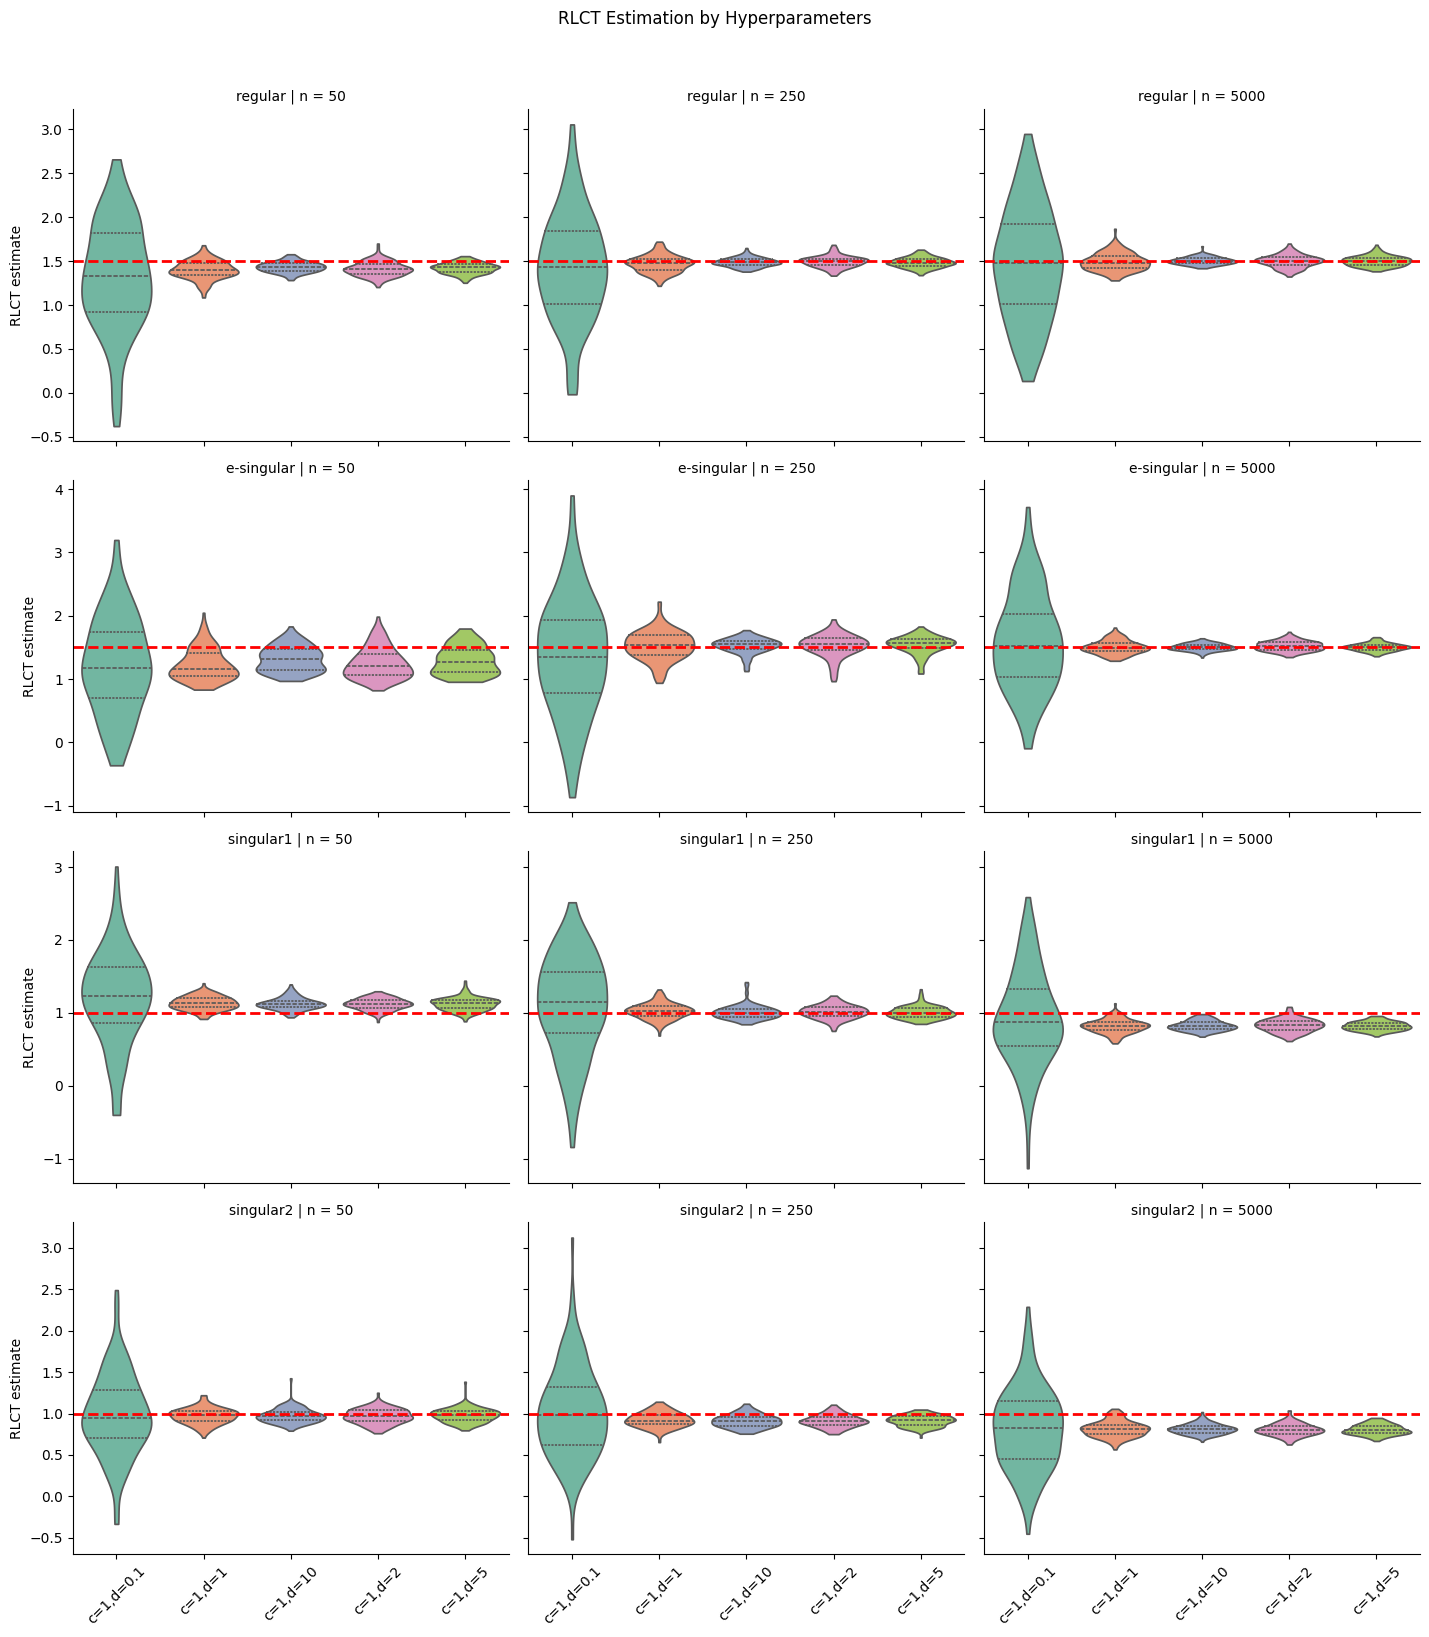

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dsids = rlct_estimates_df['dsid'].unique()
n_values = sorted(rlct_estimates_df['n'].unique())

g = sns.FacetGrid(
    rlct_estimates_df, 
    row='dsid', 
    col='n', 
    height=4, 
    aspect=1.2,
    sharey='row',
    row_order=dsids[::-1],
    col_order=n_values
)

g.map_dataframe(
    sns.violinplot, 
    x='hypers', 
    y='rlct', 
    hue='hypers',
    palette='Set2',
    legend=False,
    cut=0,  # Don't extend beyond data range
    inner='quart'  # Show quartiles inside violin
)

# Add true RLCT lines to each row
for i, dsid in enumerate(dsids[::-1]):
    true_rlct = rlct_by_dsid(dsid)
    for j, n in enumerate(n_values):
        ax = g.axes[i, j]
        ax.axhline(true_rlct, color='red', linestyle='--', linewidth=2)

g.set_axis_labels('', 'RLCT estimate')
g.set_titles(row_template='{row_name}', col_template='n = {col_name}')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('RLCT Estimation by Hyperparameters', y=1.02)
plt.tight_layout()
plt.show()

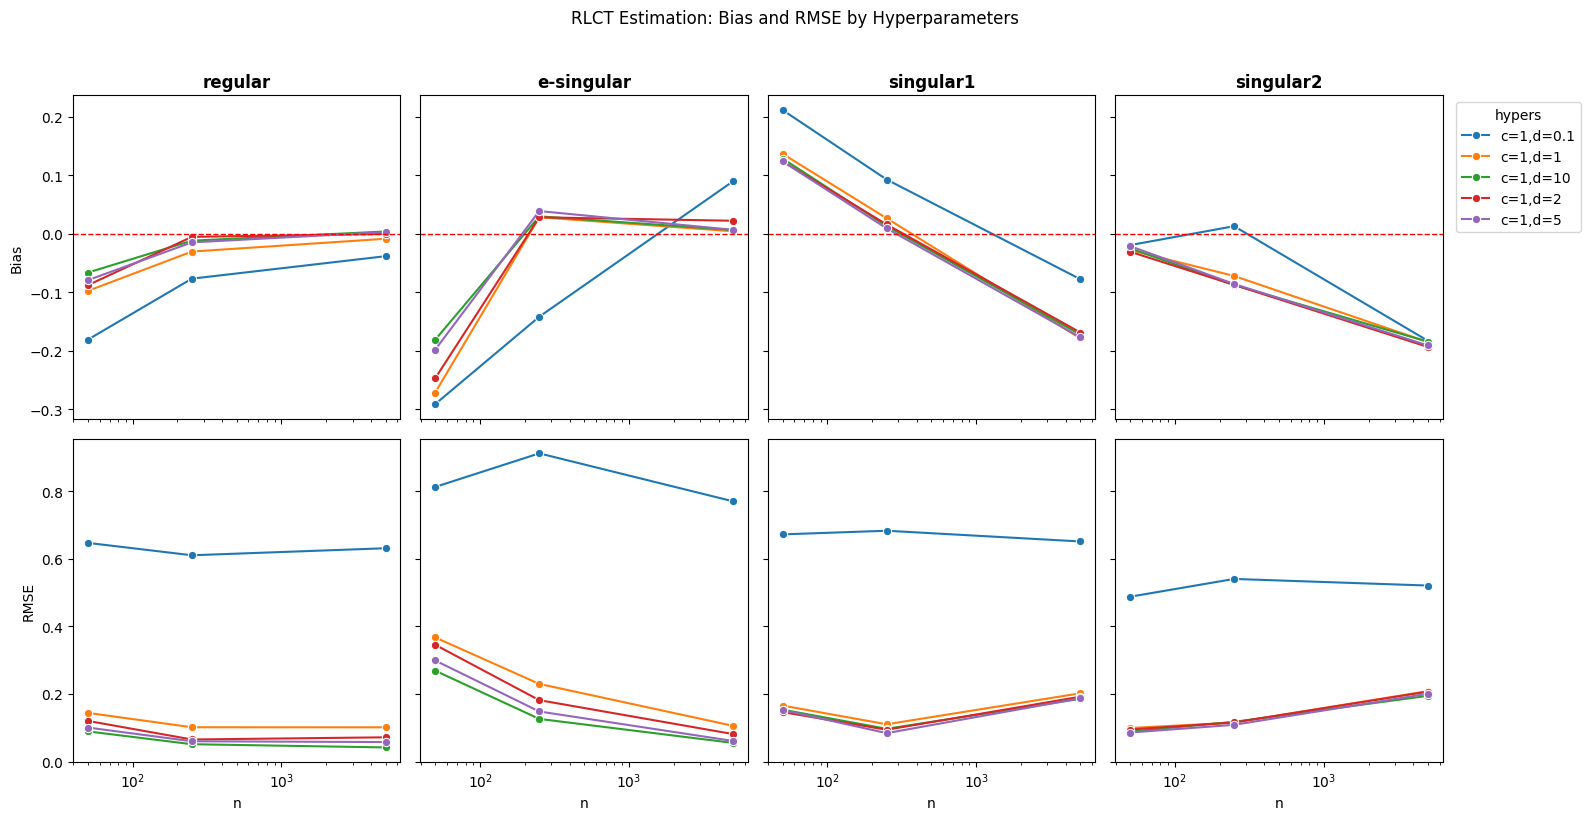

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute summary statistics
summary = rlct_estimates_df.groupby(['dsid', 'n', 'hypers']).agg(
    mean_rlct=('rlct', 'mean'),
    std_rlct=('rlct', 'std'),
    median_rlct=('rlct', 'median')
).reset_index()

# Add true RLCT and compute bias/rmse
summary['true_rlct'] = summary['dsid'].apply(rlct_by_dsid)
summary['bias'] = summary['mean_rlct'] - summary['true_rlct']
summary['rmse'] = np.sqrt(summary['bias']**2 + summary['std_rlct']**2)

dsids = ['regular', 'e-singular', 'singular1', 'singular2']

fig, axes = plt.subplots(2, len(dsids), figsize=(4*len(dsids), 8), sharex=True, sharey='row')

for j, dsid in enumerate(dsids):
    data = summary[summary['dsid'] == dsid]
    
    # Top row: Bias
    ax = axes[0, j]
    sns.lineplot(
        data=data,
        x='n',
        y='bias',
        hue='hypers',
        marker='o',
        ax=ax
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_title(dsid, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Bias' if j == 0 else '')
    
    if j < len(dsids) - 1:
        ax.get_legend().remove()
    else:
        ax.legend(title='hypers', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Bottom row: RMSE
    ax = axes[1, j]
    sns.lineplot(
        data=data,
        x='n',
        y='rmse',
        hue='hypers',
        marker='o',
        ax=ax
    )
    ax.set_xscale('log')
    ax.set_xlabel('n')
    ax.set_ylabel('RMSE' if j == 0 else '')
    ax.get_legend().remove()

plt.suptitle('RLCT Estimation: Bias and RMSE by Hyperparameters', y=1.02)
plt.tight_layout()
plt.show()

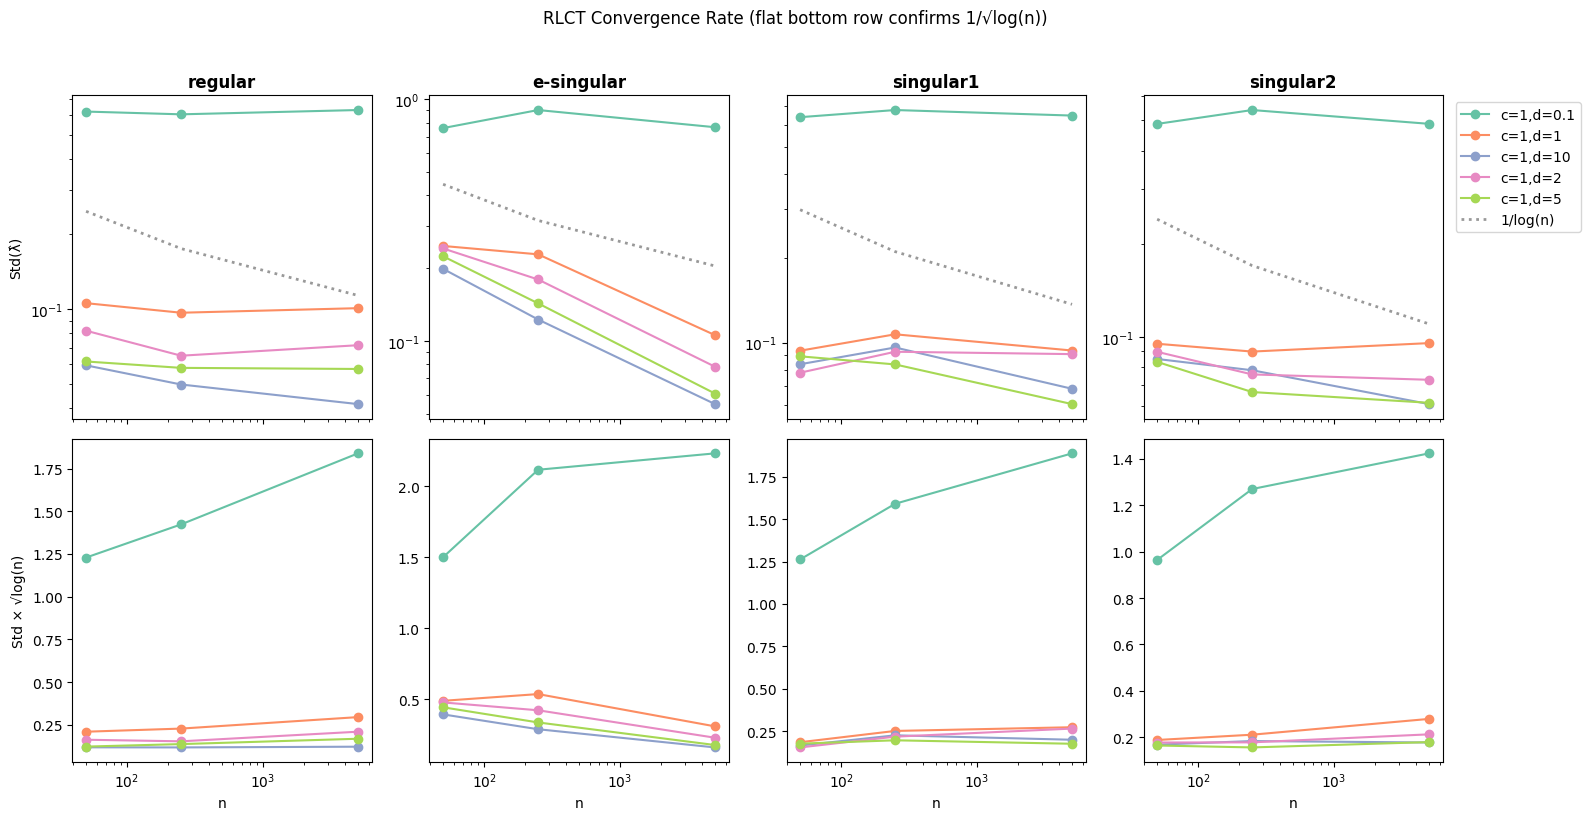

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute summary statistics
summary = rlct_estimates_df.groupby(['dsid', 'n', 'hypers']).agg(
    mean_rlct=('rlct', 'mean'),
    std_rlct=('rlct', 'std')
).reset_index()

summary['true_rlct'] = summary['dsid'].apply(rlct_by_dsid)
summary['std_normalized'] = summary['std_rlct'] * np.sqrt(np.log(summary['n']))

dsids = ['regular', 'e-singular', 'singular1', 'singular2']
hypers_list = summary['hypers'].unique()
palette = sns.color_palette('Set2', len(hypers_list))
hyper_colors = dict(zip(hypers_list, palette))

n_range = np.array(sorted(summary['n'].unique()))

fig, axes = plt.subplots(2, len(dsids), figsize=(4*len(dsids), 8), sharex=True)

for j, dsid in enumerate(dsids):
    data = summary[summary['dsid'] == dsid]
    
    # Top row: Std with reference line
    ax = axes[0, j]
    
    for hyper in hypers_list:
        hdata = data[data['hypers'] == hyper].sort_values('n')
        ax.plot(hdata['n'], hdata['std_rlct'], 'o-', 
                label=hyper, color=hyper_colors[hyper])
    
    # Reference line anchored at midpoint
    mid_idx = len(n_range) // 2
    ref_n = n_range[mid_idx]
    ref_std = data.groupby('n')['std_rlct'].mean().iloc[mid_idx]
    
    ax.plot(n_range, ref_std * (np.log(ref_n) / np.log(n_range)), 
            'k:', alpha=0.4, linewidth=2, label='1/log(n)')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_ylabel('Std(λ̂)' if j == 0 else '')
    ax.set_title(dsid, fontweight='bold')
    
    if j == len(dsids) - 1:
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Bottom row: Std × √log(n)
    ax = axes[1, j]
    
    for hyper in hypers_list:
        hdata = data[data['hypers'] == hyper].sort_values('n')
        ax.plot(hdata['n'], hdata['std_normalized'], 'o-', 
                label=hyper, color=hyper_colors[hyper])
    
    ax.set_xscale('log')
    ax.set_xlabel('n')
    ax.set_ylabel('Std × √log(n)' if j == 0 else '')
    ax.get_legend().remove() if ax.get_legend() else None

plt.suptitle('RLCT Convergence Rate (flat bottom row confirms 1/√log(n))', y=1.02)
plt.tight_layout()
plt.show()